# **Messages in LangGraph**
Messages are structured objects used to represent conversations between users, AI models and tools. They help maintain context and conversation history across workflow executions.

### **Types of Messages**

**1. HumanMessage**
* Represents user input.
* Sent by the user to the LLM.

**2. AIMessage**
* Represents the LLM's response.
* Generated by the AI model.

**3. SystemMessage**
* Provides instructions or behavior guidelines to the LLM.
* Defines the role, rules or context for the model.

**4. ToolMessage**
* Contains the output returned by a tool.
* Used when an agent invokes external tools.

### Why Use Messages?
* Maintain conversation history.
* Enable multi-turn interactions.
* Support agent and tool workflows.
* Provide structured communication between components.

### Conversation Flow

```text
SystemMessage
      ↓
HumanMessage
      ↓
AIMessage
      ↓
ToolMessage (optional)
      ↓
AIMessage
```

**Key Idea:** Messages are the fundamental communication units used to exchange information between users, LLMs, tools and agents.


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("GEMINI API Key is set.")
else:
    raise ValueError("OpenAI API Key is not set.")

GEMINI API Key is set.


In [6]:
from langchain_core.messages import HumanMessage
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

# so when you invoke the llm with a query like 
# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
# LangGraph will automatically wrap it inside HumanMessage & inside it , Its write the content as your query under the hood.just like 
# llm.invoke([HumanMessage(content="I want to know the meaning of water")]).content

In [8]:
from typing import TypedDict,List, Annotated
from operator import add # to add more in the existing 

class graph_schema(TypedDict):
    

    # Both store conversation history.
    messages_manual: List
    #Using Reducer in Langgraph , Whenever a node returns a new list,don't replace the old list.Instead:old_list + new_list
    messages_auto: Annotated[List,add] # here the add will add more list in the existing 

```text
Initial State

{
  "messages": [
    HumanMessage("something")
  ]
}
        │
        ▼
┌─────────┐
│ Node 1  │
└─────────┘
        │ Adds AIMessage
        ▼
{
  "messages": [
    HumanMessage("something"),
    AIMessage("something")
  ]
}
        │
        ▼
┌─────────┐
│ Node 2  │
└─────────┘
        │ Adds AIMessage
        ▼
{
  "messages": [
    HumanMessage("something"),
    AIMessage("something"),
    AIMessage("something")
  ]
}
        │
        ▼
     Final State
```

**Key Idea:** Each node reads the current `messages` list from the state, adds a new message, updates the state, and passes the updated state to the next node.


In [ ]:
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:

     # ===== MANUAL STATE UPDATE =====
    # Read existing conversation history from state
    messages_manual = state['messages_manual']

    # Send complete history to LLM
    response_manual = llm.invoke(messages_manual).content 

    # Convert LLM response into an AIMessage object
    response__manual_ai = AIMessage(content=response_manual)

    # Manually append new AI message to existing history
    # We are responsible for maintaining the conversation history
    state['messages_manual'] = messages_manual + [response__manual_ai]


    # ===== AUTOMATIC STATE UPDATE USING REDUCER =====
    # Read existing conversation history from state
    messages_auto = state['messages_auto']
    # Send complete history to LLM
    response_auto = llm.invoke(messages_auto).content
    # Convert LLM response into an AIMessage object
    response_auto_ai = AIMessage(content=response_auto)

    # Return only the new message
    # Reducer (Annotated[List, add]) automatically appends it
    # to the existing state instead of replacing it : old_list + new_list
    state['messages_auto'] = [response_auto_ai]

    # Return updated state to LangGraph
    return state


def curate_post(state: graph_schema) -> graph_schema:


    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response__manual_ai = AIMessage(content=response_manual)
    state['messages_manual'] = messages_manual + [response__manual_ai]

    messages_auto = state['messages_auto']
    response_auto = llm.invoke(messages_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state['messages_auto'] = [response_auto_ai]


    return state


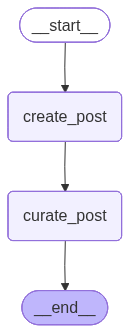

In [10]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(messages_graph.get_graph().draw_mermaid_png())

In [ ]:
 messages_graph.invoke(
     {"messages_manual": [HumanMessage(content="The importance of data privacy in the digital age")],
      "messages_auto": [HumanMessage(content="The importance of data privacy in the digital age")]}
 )

In [16]:
# Example containing four different types of messages.
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    ToolMessage
)

# SYSTEM MESSAGE
# Defines the behavior/rules for the AI
system_msg = SystemMessage(
    content="You are a helpful weather assistant."
)

# HUMAN MESSAGE
# User asks a question
human_msg = HumanMessage(
    content="What is the weather in Bangalore today?"
)

# AI MESSAGE
# AI decides that it needs a weather tool
ai_tool_request = AIMessage(
    content="I will check the weather using the weather tool."
)

# TOOL MESSAGE
# Result returned by the external tool/API
tool_msg = ToolMessage(
    content="Temperature: 28°C, Condition: Sunny",
    tool_call_id="weather_tool_1"
)

# AI MESSAGE
# Final response generated using tool output
final_ai_msg = AIMessage(
    content="The weather in Bangalore is sunny with a temperature of 28°C."
)

messages = [
    system_msg,
    human_msg,
    ai_tool_request,
    tool_msg,
    final_ai_msg
]

for msg in messages:
    print(type(msg).__name__, ":", msg.content)


# Flow:

# SystemMessage
# ↓
# HumanMessage
# ↓
# AIMessage (decides to use a tool)
# ↓
# ToolMessage (tool returns data)
# ↓
# AIMessage (final answer to user)

# ```

### What each message represents

# - **SystemMessage** → AI's instructions/role.
# - **HumanMessage** → User's query.
# - **AIMessage** → LLM's response or decision.
# - **ToolMessage** → Output returned by an external tool/API.

# ### Interview One-Liner

# A typical agent workflow is: **SystemMessage → HumanMessage → AIMessage (tool request) → ToolMessage (tool output) → AIMessage (final response).**
# ```


SystemMessage : You are a helpful weather assistant.
HumanMessage : What is the weather in Bangalore today?
AIMessage : I will check the weather using the weather tool.
ToolMessage : Temperature: 28°C, Condition: Sunny
AIMessage : The weather in Bangalore is sunny with a temperature of 28°C.
